# Titanic Dataset — Data Cleaning & Exploratory Data Analysis



---

## Objective

Perform data cleaning and exploratory data analysis (EDA).

---

## 1️⃣ Import Libraries

In [186]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuration
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Custom color palette
COLORS = {
    'survived': '#2ecc71',
    'not_survived': '#e74c3c',
    'primary': '#3498db',
    'secondary': '#9b59b6',
    'accent': '#f39c12'
}
SURVIVAL_PALETTE = {0: COLORS['not_survived'], 1: COLORS['survived']}
SURVIVAL_PALETTE_STR = {'0': COLORS['not_survived'], '1': COLORS['survived']}

print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


---
## 2️⃣ Data Loading & Initial Inspection

Let's load the Titanic dataset and understand its structure.

In [187]:
# Load datasets
train = pd.read_csv('titanic/train.csv')
test = pd.read_csv('titanic/test.csv')

print(f'Training set shape: {train.shape}')
print(f'Test set shape: {test.shape}')
print(f'\nTotal passengers: {train.shape[0] + test.shape[0]}')

Training set shape: (891, 12)
Test set shape: (418, 11)

Total passengers: 1309


### First 10 Rows of Training Data

In [188]:
train.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


### Last 5 Rows of Training Data

In [189]:
train.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


### Dataset Information

In [190]:
print('=' * 60)
print('TRAINING SET INFO')
print('=' * 60)
train.info()
print('\n')
print('=' * 60)
print('TEST SET INFO')
print('=' * 60)
test.info()

TRAINING SET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


TEST SET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418

### Statistical Summary — Numerical Features

In [191]:
train.describe().round(2)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


### Statistical Summary — Categorical Features

In [192]:
train.describe(include='object')

,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


---
## 3️⃣ Missing Values Analysis

Before cleaning, let's understand the extent and distribution of missing data.

In [193]:
# Missing values summary for both datasets
def missing_values_table(df, name='Dataset'):
    """Create a comprehensive missing values summary table."""
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)
    dtypes = df.dtypes
    
    table = pd.DataFrame({
        'Missing Values': missing,
        'Percentage (%)': missing_pct,
        'Data Type': dtypes
    })
    table = table[table['Missing Values'] > 0].sort_values('Percentage (%)', ascending=False)
    
    print(f'\n{"=" * 50}')
    print(f'  Missing Values Summary — {name}')
    print(f'{"=" * 50}')
    if len(table) == 0:
        print('  No missing values found!')
    else:
        print(table.to_string())
    print(f'\nTotal rows: {len(df)}')
    return table

train_missing = missing_values_table(train, 'Training Set')
test_missing = missing_values_table(test, 'Test Set')


  Missing Values Summary — Training Set
          Missing Values  Percentage (%) Data Type
Cabin                687           77.10    object
Age                  177           19.87   float64
Embarked               2            0.22    object

Total rows: 891

  Missing Values Summary — Test Set
       Missing Values  Percentage (%) Data Type
Cabin             327           78.23    object
Age                86           20.57   float64
Fare                1            0.24   float64

Total rows: 418


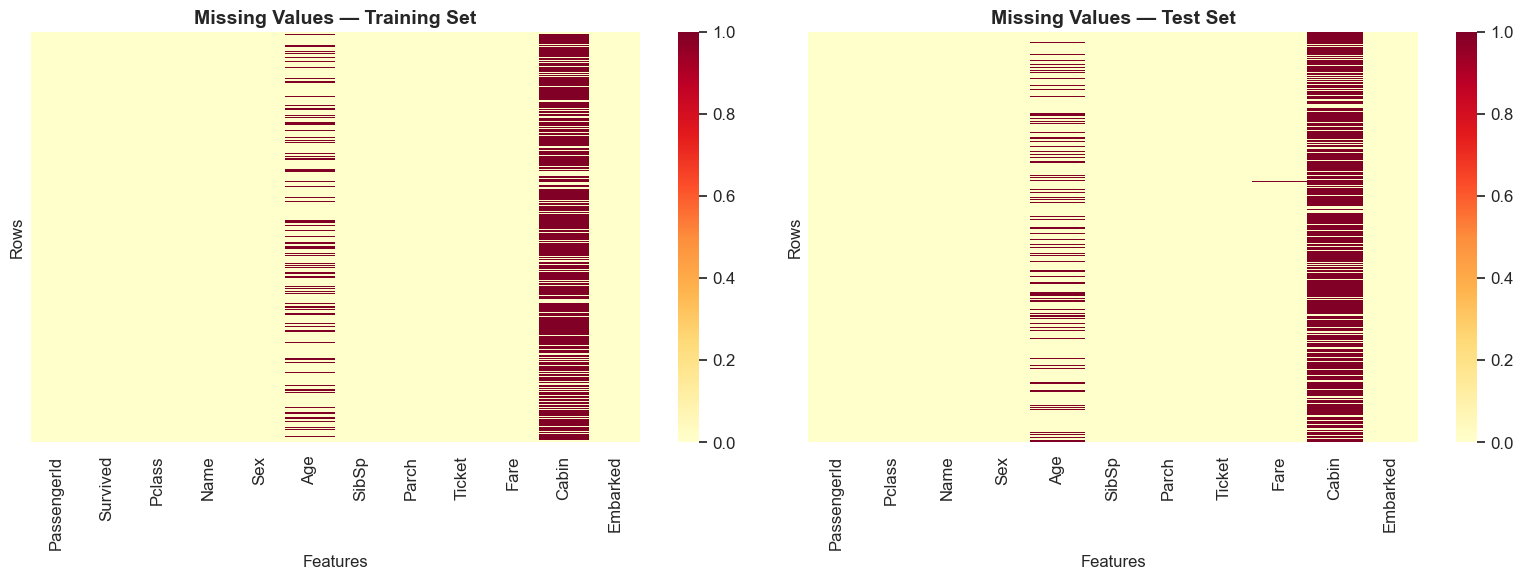


🔍 Observations:
  • Age: ~20% missing in train — needs careful imputation
  • Cabin: ~77% missing in train — too many missing, will extract deck info
  • Embarked: Only 2 missing in train — can fill with mode


In [194]:
# Visualize missing values with a heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Training set
sns.heatmap(train.isnull(), cbar=True, yticklabels=False, cmap='YlOrRd', ax=axes[0])
axes[0].set_title('Missing Values — Training Set', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Features')
axes[0].set_ylabel('Rows')

# Test set
sns.heatmap(test.isnull(), cbar=True, yticklabels=False, cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Missing Values — Test Set', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Features')
axes[1].set_ylabel('Rows')

plt.tight_layout()
plt.show()

print('\n🔍 Observations:')
print('  • Age: ~20% missing in train — needs careful imputation')
print('  • Cabin: ~77% missing in train — too many missing, will extract deck info')
print('  • Embarked: Only 2 missing in train — can fill with mode')

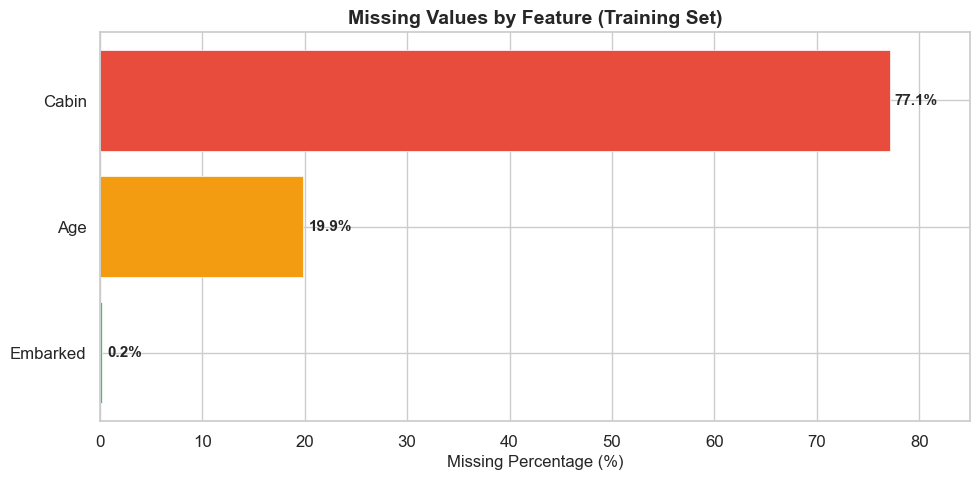

In [195]:
# Bar chart of missing values percentage
fig, ax = plt.subplots(figsize=(10, 5))

missing_pct = (train.isnull().sum() / len(train) * 100).sort_values(ascending=True)
missing_pct = missing_pct[missing_pct > 0]

bars = ax.barh(missing_pct.index, missing_pct.values, color=['#e74c3c' if v > 50 else '#f39c12' if v > 10 else '#2ecc71' for v in missing_pct.values],
               edgecolor='white', linewidth=0.5)

# Add percentage labels
for bar, val in zip(bars, missing_pct.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
            f'{val:.1f}%', va='center', fontweight='bold', fontsize=11)

ax.set_xlabel('Missing Percentage (%)')
ax.set_title('Missing Values by Feature (Training Set)', fontsize=14, fontweight='bold')
ax.set_xlim(0, 85)
plt.tight_layout()
plt.show()

---
## 4️⃣ Data Cleaning

Now we'll handle the missing values using intelligent imputation strategies.

### 4.1 Handling Missing `Age` Values

Instead of using a simple mean/median, we'll impute Age based on **Pclass** and **Sex** groups 
for more accurate imputation.

In [196]:
# Impute Age based on Pclass and Sex median
print('Age imputation strategy: Median by Pclass × Sex')
print('-' * 45)

age_medians = train.groupby(['Pclass', 'Sex'])['Age'].median()
print(age_medians)

# Apply imputation to both datasets
for dataset in [train, test]:
    for pclass in dataset['Pclass'].unique():
        for sex in dataset['Sex'].unique():
            median_age = age_medians.get((pclass, sex), dataset['Age'].median())
            mask = (dataset['Pclass'] == pclass) & (dataset['Sex'] == sex) & (dataset['Age'].isnull())
            dataset.loc[mask, 'Age'] = median_age

print(f'\n✅ Age missing values after imputation:')
print(f'  Train: {train["Age"].isnull().sum()}')
print(f'  Test:  {test["Age"].isnull().sum()}')

Age imputation strategy: Median by Pclass × Sex
---------------------------------------------
Pclass  Sex   
1       female    35.0
        male      40.0
2       female    28.0
        male      30.0
3       female    21.5
        male      25.0
Name: Age, dtype: float64

✅ Age missing values after imputation:
  Train: 0
  Test:  0


### 4.2 Handling Missing `Cabin` Values

Since Cabin has ~77% missing data, we'll extract the **deck letter** (first character) 
and mark missing cabins as 'Unknown'.

In [197]:
# Extract deck from Cabin
for dataset in [train, test]:
    dataset['Deck'] = dataset['Cabin'].apply(lambda x: x[0] if pd.notna(x) else 'Unknown')

print('Deck distribution (Training Set):')
print(train['Deck'].value_counts())
print(f'\n✅ Created "Deck" feature from Cabin')

Deck distribution (Training Set):
Deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64

✅ Created "Deck" feature from Cabin


### 4.3 Handling Missing `Embarked` Values

In [198]:
# Fill Embarked with mode (most frequent value)
embarked_mode = train['Embarked'].mode()[0]
print(f'Embarked mode: {embarked_mode}')

train['Embarked'].fillna(embarked_mode, inplace=True)
test['Embarked'].fillna(embarked_mode, inplace=True)

print(f'✅ Embarked missing values filled with "{embarked_mode}"')
print(f'   Train missing: {train["Embarked"].isnull().sum()}')

Embarked mode: S
✅ Embarked missing values filled with "S"
   Train missing: 0


### 4.4 Handling Missing `Fare` Values (Test Set)

In [199]:
# Fill missing Fare in test set with median based on Pclass
fare_median = test.groupby('Pclass')['Fare'].median()
print('Fare median by Pclass:')
print(fare_median)

for pclass in test['Pclass'].unique():
    mask = (test['Pclass'] == pclass) & (test['Fare'].isnull())
    test.loc[mask, 'Fare'] = fare_median[pclass]

print(f'\n✅ Fare missing values filled: {test["Fare"].isnull().sum()} remaining')

Fare median by Pclass:
Pclass
1    60.0000
2    15.7500
3     7.8958
Name: Fare, dtype: float64

✅ Fare missing values filled: 0 remaining


### 4.5 Verify Data Cleaning

In [200]:
# Final check on missing values
print('Missing values after cleaning:')
print('=' * 40)
print('\nTraining Set:')
remaining_train = train[['Age', 'Embarked', 'Fare', 'Deck']].isnull().sum()
print(remaining_train)
print(f'\nTest Set:')
remaining_test = test[['Age', 'Fare', 'Deck']].isnull().sum()
print(remaining_test)
print('\n✅ All critical missing values have been handled!')

Missing values after cleaning:

Training Set:
Age         0
Embarked    0
Fare        0
Deck        0
dtype: int64

Test Set:
Age     0
Fare    0
Deck    0
dtype: int64

✅ All critical missing values have been handled!


---
## 5️⃣ Feature Engineering

Creating new features to better capture the underlying patterns in the data.

### 5.1 Extract Title from Name

In [201]:
# Extract Title from Name
for dataset in [train, test]:
    dataset['Title'] = dataset['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

print('Title distribution (Training Set):')
print(train['Title'].value_counts())

# Group rare titles
title_mapping = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
    'Dr': 'Rare', 'Rev': 'Rare', 'Col': 'Rare', 'Major': 'Rare',
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs', 'Don': 'Rare',
    'Dona': 'Rare', 'Lady': 'Rare', 'Countess': 'Rare', 'Jonkheer': 'Rare',
    'Sir': 'Rare', 'Capt': 'Rare'
}

for dataset in [train, test]:
    dataset['Title'] = dataset['Title'].map(title_mapping).fillna('Rare')

print('\nAfter grouping:')
print(train['Title'].value_counts())

Title distribution (Training Set):
Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Mlle          2
Major         2
Col           2
Countess      1
Capt          1
Ms            1
Sir           1
Lady          1
Mme           1
Don           1
Jonkheer      1
Name: count, dtype: int64

After grouping:
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


### 5.2 Create Family Size & IsAlone

In [202]:
# Family Size = SibSp + Parch + 1 (self)
for dataset in [train, test]:
    dataset['FamilySize'] = dataset['SibSp'] + dataset['Parch'] + 1
    dataset['IsAlone'] = (dataset['FamilySize'] == 1).astype(int)

print('Family Size distribution:')
print(train['FamilySize'].value_counts().sort_index())
print(f'\nAlone passengers: {train["IsAlone"].sum()} ({train["IsAlone"].mean()*100:.1f}%)')
print(f'With family:      {(train["IsAlone"]==0).sum()} ({(1-train["IsAlone"].mean())*100:.1f}%)')

Family Size distribution:
FamilySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

Alone passengers: 537 (60.3%)
With family:      354 (39.7%)


### 5.3 Create Age Groups

In [203]:
# Create age groups
age_bins = [0, 12, 18, 30, 50, 80]
age_labels = ['Child', 'Teenager', 'Young Adult', 'Adult', 'Senior']

for dataset in [train, test]:
    dataset['AgeGroup'] = pd.cut(dataset['Age'], bins=age_bins, labels=age_labels)

print('Age Group distribution:')
print(train['AgeGroup'].value_counts().sort_index())

Age Group distribution:
AgeGroup
Child           69
Teenager        70
Young Adult    417
Adult          271
Senior          64
Name: count, dtype: int64


### 5.4 Create Fare Bands

In [204]:
# Create fare bands using quartiles
for dataset in [train, test]:
    dataset['FareBand'] = pd.qcut(dataset['Fare'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])

print('Fare Band distribution:')
print(train['FareBand'].value_counts().sort_index())
print('\nFare Band ranges:')
for band in ['Low', 'Medium', 'High', 'Very High']:
    subset = train[train['FareBand'] == band]['Fare']
    print(f'  {band:>9}: ${subset.min():.2f} — ${subset.max():.2f}')

Fare Band distribution:
FareBand
Low          223
Medium       224
High         222
Very High    222
Name: count, dtype: int64

Fare Band ranges:
        Low: $0.00 — $7.90
     Medium: $7.92 — $14.45
       High: $14.46 — $31.00
  Very High: $31.27 — $512.33


### 5.5 Summary of Engineered Features

In [205]:
# Overview of all features after engineering
print('Dataset columns after feature engineering:')
print('=' * 50)
new_features = ['Title', 'FamilySize', 'IsAlone', 'AgeGroup', 'FareBand', 'Deck']
for col in train.columns:
    marker = ' ✨ NEW' if col in new_features else ''
    print(f'  {col:<15} {str(train[col].dtype):<12} {marker}')
print(f'\nTotal features: {len(train.columns)}')
print(f'New features added: {len(new_features)}')

Dataset columns after feature engineering:
  PassengerId     int64        
  Survived        int64        
  Pclass          int64        
  Name            object       
  Sex             object       
  Age             float64      
  SibSp           int64        
  Parch           int64        
  Ticket          object       
  Fare            float64      
  Cabin           object       
  Embarked        object       
  Deck            object        ✨ NEW
  Title           object        ✨ NEW
  FamilySize      int64         ✨ NEW
  IsAlone         int64         ✨ NEW
  AgeGroup        category      ✨ NEW
  FareBand        category      ✨ NEW

Total features: 18
New features added: 6


---
## 6️⃣ Univariate Analysis

Examining the distribution of individual variables.

### 6.1 Target Variable — Survival Distribution

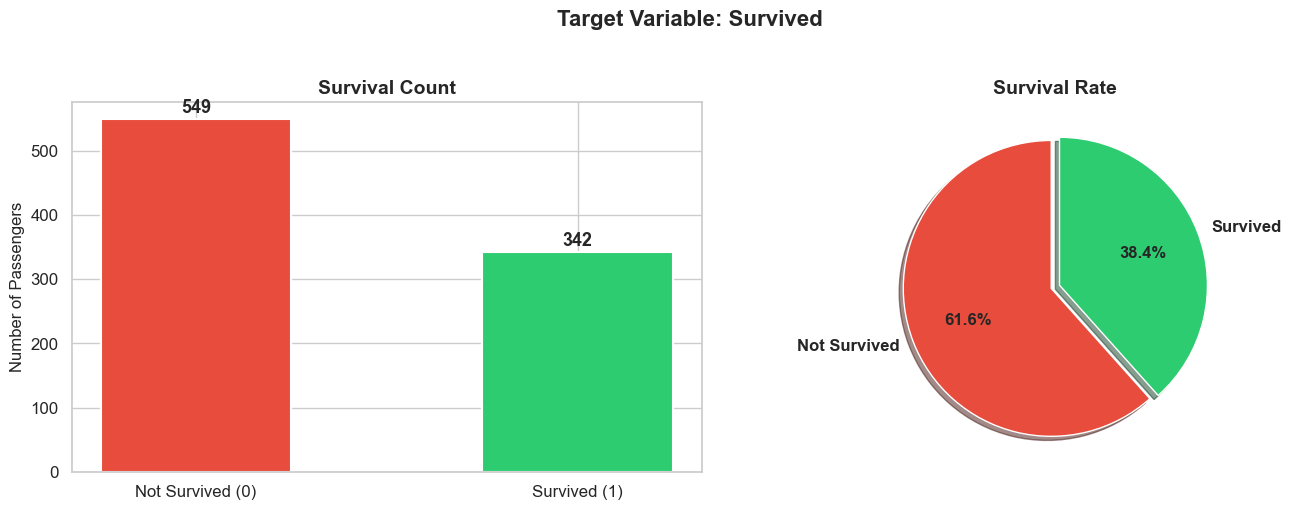


📊 Survival Rate: 38.4% survived, 61.6% did not survive


In [206]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
survived_counts = train['Survived'].value_counts()
bars = axes[0].bar(['Not Survived (0)', 'Survived (1)'], survived_counts.values,
                    color=[COLORS['not_survived'], COLORS['survived']], 
                    edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, survived_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val}', ha='center', fontweight='bold', fontsize=13)
axes[0].set_title('Survival Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Passengers')

# Pie chart
survived_pct = train['Survived'].value_counts(normalize=True) * 100
axes[1].pie(survived_pct.values, labels=['Not Survived', 'Survived'],
            colors=[COLORS['not_survived'], COLORS['survived']],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'},
            explode=(0.03, 0.03), shadow=True)
axes[1].set_title('Survival Rate', fontsize=14, fontweight='bold')

plt.suptitle('Target Variable: Survived', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\n📊 Survival Rate: {survived_pct[1]:.1f}% survived, {survived_pct[0]:.1f}% did not survive')

### 6.2 Age Distribution

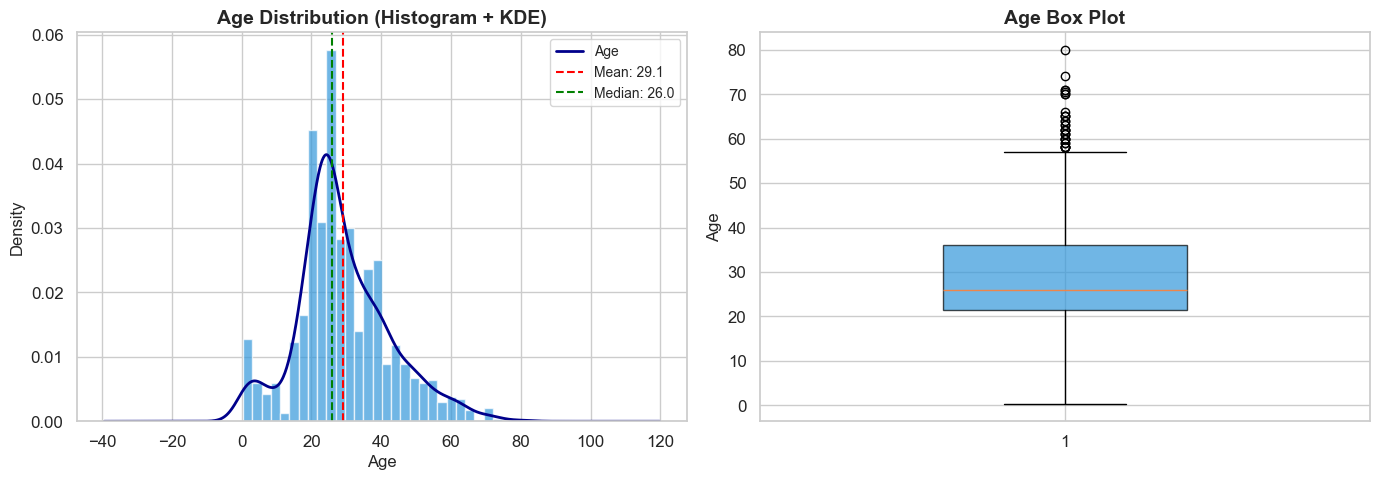


📊 Age Statistics:
  Mean: 29.1 years
  Median: 26.0 years
  Std Dev: 13.3 years
  Min: 0.4, Max: 80.0


In [207]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with KDE
axes[0].hist(train['Age'], bins=30, color=COLORS['primary'], alpha=0.7, edgecolor='white', density=True)
train['Age'].plot(kind='kde', ax=axes[0], color='darkblue', linewidth=2)
axes[0].set_title('Age Distribution (Histogram + KDE)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Density')
axes[0].axvline(train['Age'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: {train["Age"].mean():.1f}')
axes[0].axvline(train['Age'].median(), color='green', linestyle='--', linewidth=1.5, label=f'Median: {train["Age"].median():.1f}')
axes[0].legend(fontsize=10)

# Box plot
bp = axes[1].boxplot(train['Age'].dropna(), patch_artist=True, widths=0.4)
bp['boxes'][0].set_facecolor(COLORS['primary'])
bp['boxes'][0].set_alpha(0.7)
axes[1].set_title('Age Box Plot', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Age')

plt.tight_layout()
plt.show()

print(f'\n📊 Age Statistics:')
print(f'  Mean: {train["Age"].mean():.1f} years')
print(f'  Median: {train["Age"].median():.1f} years')
print(f'  Std Dev: {train["Age"].std():.1f} years')
print(f'  Min: {train["Age"].min():.1f}, Max: {train["Age"].max():.1f}')

### 6.3 Fare Distribution

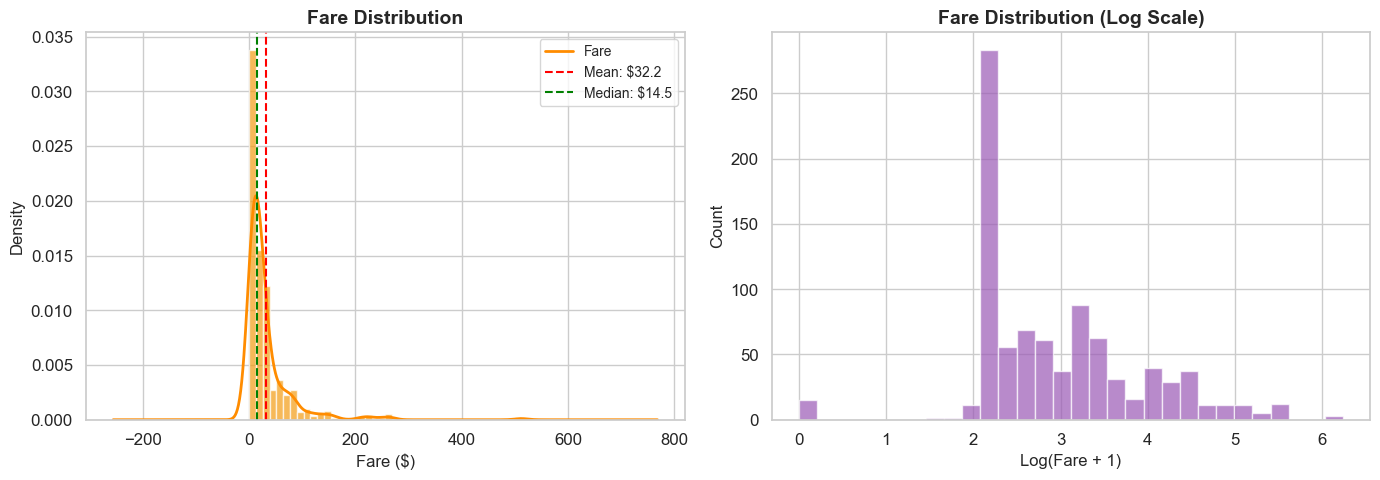


📊 Fare is right-skewed (skewness: 4.79)
  Most passengers paid under $31.0


In [208]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with KDE
axes[0].hist(train['Fare'], bins=40, color=COLORS['accent'], alpha=0.7, edgecolor='white', density=True)
train['Fare'].plot(kind='kde', ax=axes[0], color='darkorange', linewidth=2)
axes[0].set_title('Fare Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Fare ($)')
axes[0].set_ylabel('Density')
axes[0].axvline(train['Fare'].mean(), color='red', linestyle='--', linewidth=1.5, label=f'Mean: ${train["Fare"].mean():.1f}')
axes[0].axvline(train['Fare'].median(), color='green', linestyle='--', linewidth=1.5, label=f'Median: ${train["Fare"].median():.1f}')
axes[0].legend(fontsize=10)

# Log-transformed fare
axes[1].hist(np.log1p(train['Fare']), bins=30, color=COLORS['secondary'], alpha=0.7, edgecolor='white')
axes[1].set_title('Fare Distribution (Log Scale)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Log(Fare + 1)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f'\n📊 Fare is right-skewed (skewness: {train["Fare"].skew():.2f})')
print(f'  Most passengers paid under ${train["Fare"].quantile(0.75):.1f}')

### 6.4 Categorical Features Distribution

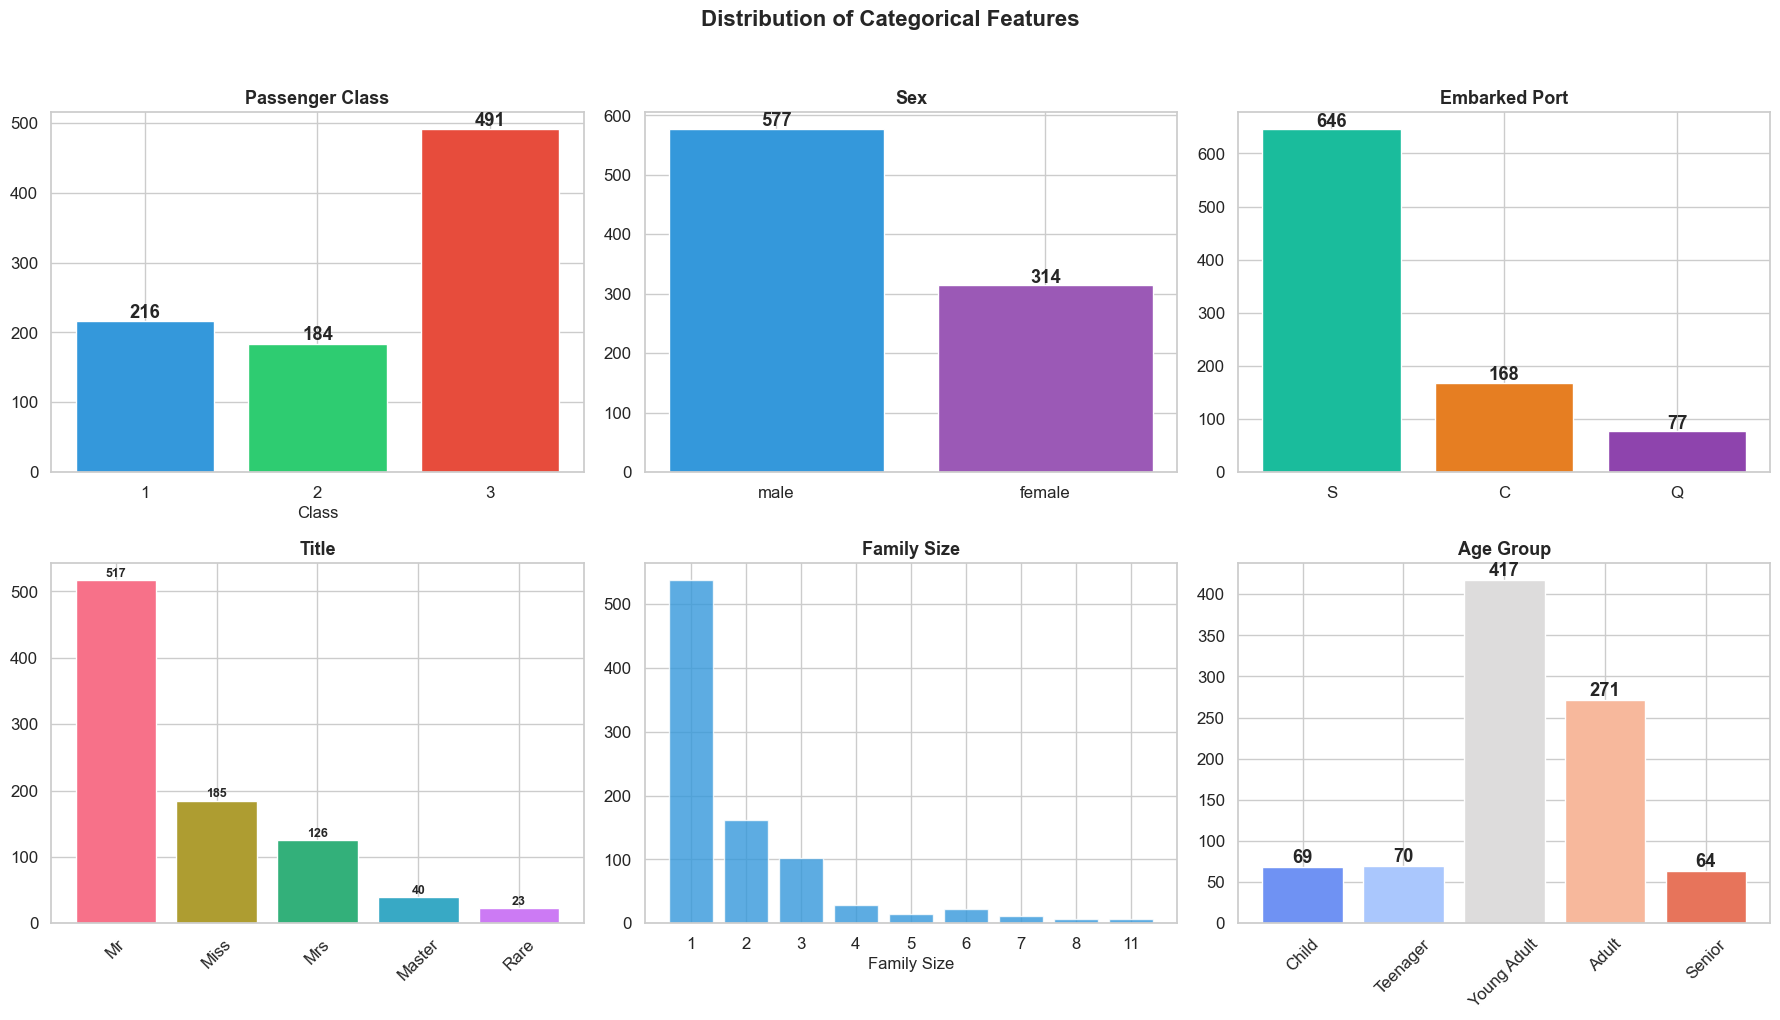

In [209]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Passenger Class
pclass_counts = train['Pclass'].value_counts().sort_index()
colors_pclass = ['#3498db', '#2ecc71', '#e74c3c']
bars = axes[0, 0].bar(pclass_counts.index.astype(str), pclass_counts.values, color=colors_pclass, edgecolor='white')
for bar, val in zip(bars, pclass_counts.values):
    axes[0, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                     f'{val}', ha='center', fontweight='bold')
axes[0, 0].set_title('Passenger Class', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Class')

# Sex
sex_counts = train['Sex'].value_counts()
axes[0, 1].bar(sex_counts.index, sex_counts.values, color=[COLORS['primary'], COLORS['secondary']], edgecolor='white')
for i, (idx, val) in enumerate(sex_counts.items()):
    axes[0, 1].text(i, val + 5, f'{val}', ha='center', fontweight='bold')
axes[0, 1].set_title('Sex', fontsize=13, fontweight='bold')

# Embarked
emb_counts = train['Embarked'].value_counts()
axes[0, 2].bar(emb_counts.index, emb_counts.values, color=['#1abc9c', '#e67e22', '#8e44ad'], edgecolor='white')
for i, (idx, val) in enumerate(emb_counts.items()):
    axes[0, 2].text(i, val + 5, f'{val}', ha='center', fontweight='bold')
axes[0, 2].set_title('Embarked Port', fontsize=13, fontweight='bold')

# Title
title_counts = train['Title'].value_counts()
axes[1, 0].bar(title_counts.index, title_counts.values, color=sns.color_palette('husl', len(title_counts)), edgecolor='white')
for i, (idx, val) in enumerate(title_counts.items()):
    axes[1, 0].text(i, val + 5, f'{val}', ha='center', fontweight='bold', fontsize=9)
axes[1, 0].set_title('Title', fontsize=13, fontweight='bold')
axes[1, 0].tick_params(axis='x', rotation=45)

# Family Size
fs_counts = train['FamilySize'].value_counts().sort_index()
axes[1, 1].bar(fs_counts.index.astype(str), fs_counts.values, color=COLORS['primary'], alpha=0.8, edgecolor='white')
axes[1, 1].set_title('Family Size', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Family Size')

# Age Group
ag_counts = train['AgeGroup'].value_counts().sort_index()
axes[1, 2].bar(ag_counts.index.astype(str), ag_counts.values, color=sns.color_palette('coolwarm', len(ag_counts)), edgecolor='white')
for i, val in enumerate(ag_counts.values):
    axes[1, 2].text(i, val + 5, f'{val}', ha='center', fontweight='bold')
axes[1, 2].set_title('Age Group', fontsize=13, fontweight='bold')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.suptitle('Distribution of Categorical Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 7️⃣ Bivariate Analysis

Exploring the relationship between each feature and the survival outcome.

### 7.1 Survival Rate by Sex

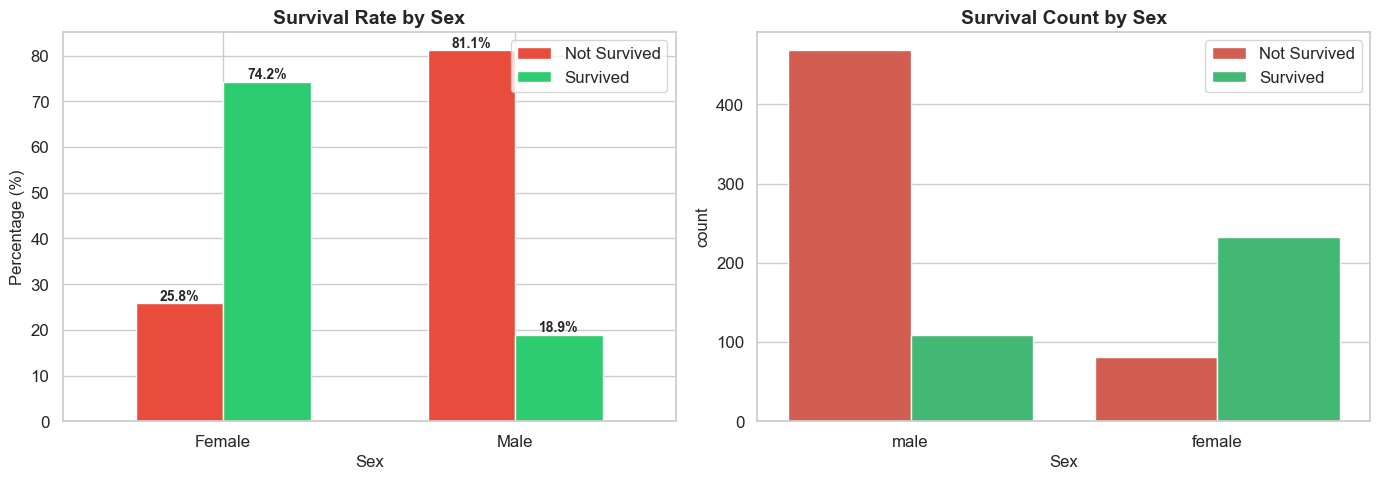


📊 Key Finding:
  Female survival rate: 74.2%
  Male survival rate:   18.9%
  → Women were ~3.9x more likely to survive ("Women and children first")


In [210]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Grouped bar chart
survival_by_sex = train.groupby('Sex')['Survived'].value_counts(normalize=True).unstack() * 100
survival_by_sex.plot(kind='bar', ax=axes[0], color=[COLORS['not_survived'], COLORS['survived']],
                      edgecolor='white', width=0.6)
axes[0].set_title('Survival Rate by Sex', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xticklabels(['Female', 'Male'], rotation=0)
axes[0].legend(['Not Survived', 'Survived'], loc='upper right')

# Add percentage labels
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f%%', fontweight='bold', fontsize=10)

# Count plot
sns.countplot(data=train, x='Sex', hue='Survived', palette=SURVIVAL_PALETTE, ax=axes[1], edgecolor='white')
axes[1].set_title('Survival Count by Sex', fontsize=14, fontweight='bold')
axes[1].legend(['Not Survived', 'Survived'])

plt.tight_layout()
plt.show()

sex_survival = train.groupby('Sex')['Survived'].mean() * 100
print(f'\n📊 Key Finding:')
print(f'  Female survival rate: {sex_survival["female"]:.1f}%')
print(f'  Male survival rate:   {sex_survival["male"]:.1f}%')
print(f'  → Women were ~{sex_survival["female"]/sex_survival["male"]:.1f}x more likely to survive ("Women and children first")')

### 7.2 Survival Rate by Passenger Class

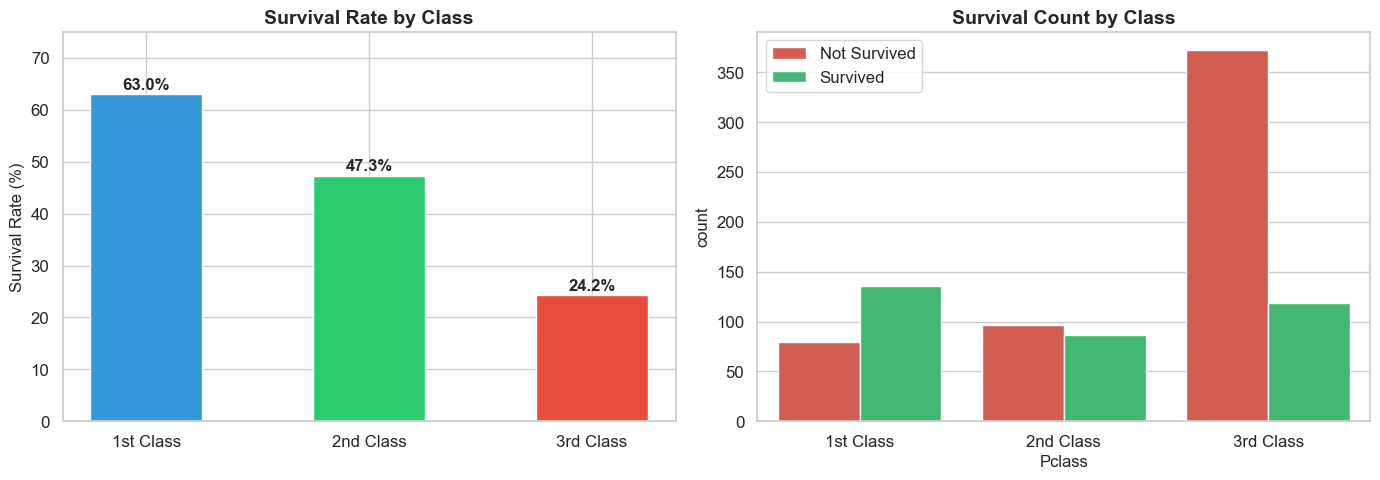


📊 Key Finding:
  1st Class survival: 63.0%
  2nd Class survival: 47.3%
  3rd Class survival: 24.2%
  → Clear socioeconomic divide: higher class = higher survival


In [211]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Survival rate bar chart
class_survival = train.groupby('Pclass')['Survived'].mean() * 100
bars = axes[0].bar(['1st Class', '2nd Class', '3rd Class'], class_survival.values,
                    color=['#3498db', '#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
for bar, val in zip(bars, class_survival.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Survival Rate by Class', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_ylim(0, 75)

# Stacked count plot
sns.countplot(data=train, x='Pclass', hue='Survived', palette=SURVIVAL_PALETTE, ax=axes[1], edgecolor='white')
axes[1].set_title('Survival Count by Class', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['1st Class', '2nd Class', '3rd Class'])
axes[1].legend(['Not Survived', 'Survived'])

plt.tight_layout()
plt.show()

print(f'\n📊 Key Finding:')
print(f'  1st Class survival: {class_survival[1]:.1f}%')
print(f'  2nd Class survival: {class_survival[2]:.1f}%')
print(f'  3rd Class survival: {class_survival[3]:.1f}%')
print(f'  → Clear socioeconomic divide: higher class = higher survival')

### 7.3 Survival Rate by Embarked Port

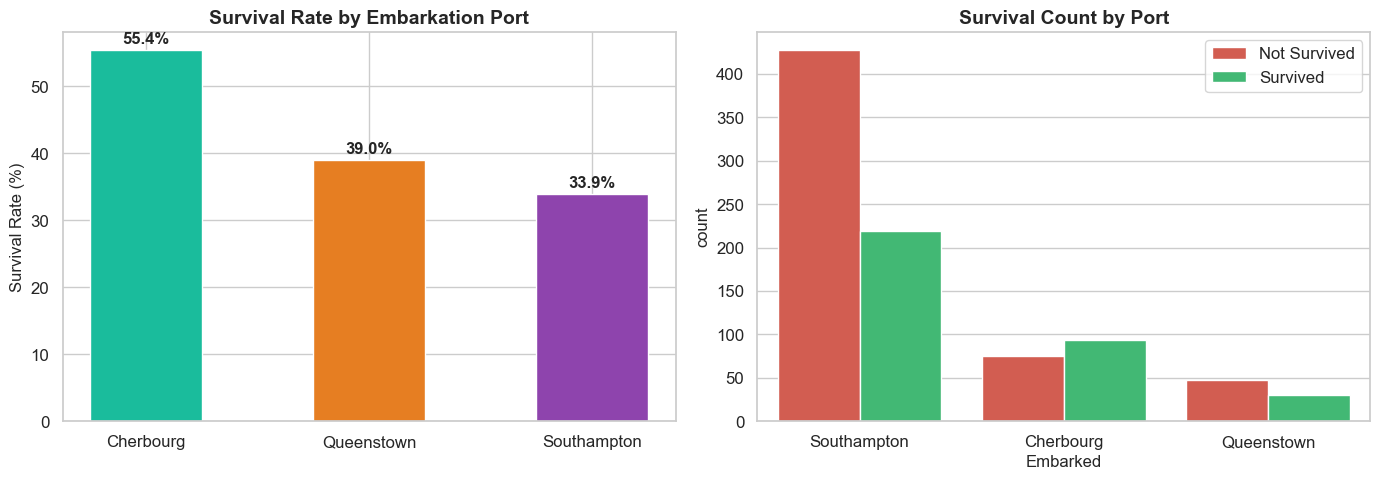


📊 Cherbourg had highest survival rate — likely more 1st class passengers boarded there


In [212]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

port_names = {'C': 'Cherbourg', 'Q': 'Queenstown', 'S': 'Southampton'}
emb_survival = train.groupby('Embarked')['Survived'].mean() * 100

# Survival rate
bars = axes[0].bar([port_names[p] for p in emb_survival.index], emb_survival.values,
                    color=['#1abc9c', '#e67e22', '#8e44ad'], edgecolor='white', width=0.5)
for bar, val in zip(bars, emb_survival.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Survival Rate by Embarkation Port', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Survival Rate (%)')

# Count plot
sns.countplot(data=train, x='Embarked', hue='Survived', palette=SURVIVAL_PALETTE, ax=axes[1], edgecolor='white')
axes[1].set_title('Survival Count by Port', fontsize=14, fontweight='bold')
axes[1].set_xticklabels([port_names.get(t.get_text(), t.get_text()) for t in axes[1].get_xticklabels()])
axes[1].legend(['Not Survived', 'Survived'])

plt.tight_layout()
plt.show()

print(f'\n📊 Cherbourg had highest survival rate — likely more 1st class passengers boarded there')

### 7.4 Survival Rate by Title

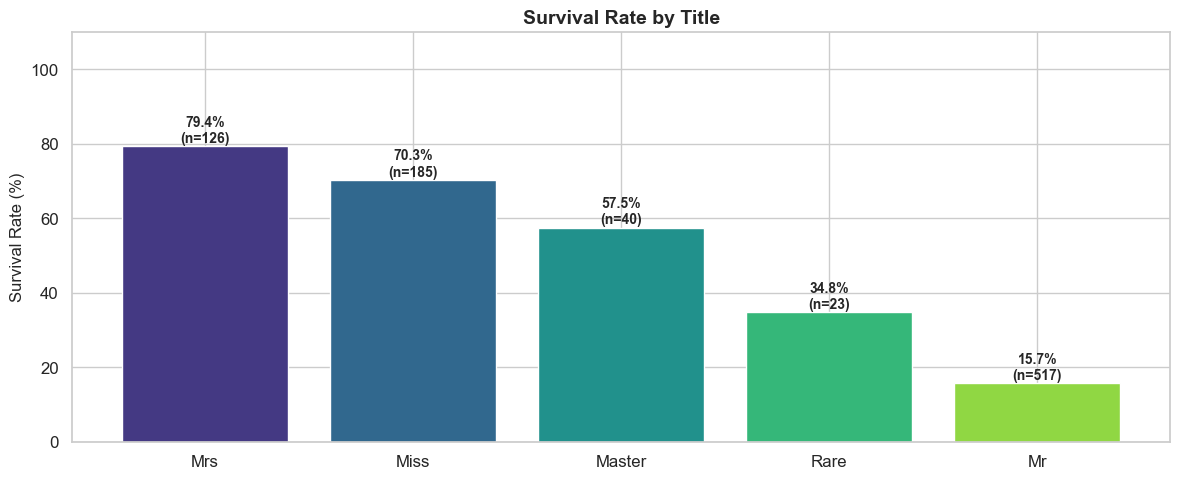


📊 "Mrs" and "Miss" had the highest survival rates — confirms gender-based priority


In [213]:
fig, ax = plt.subplots(figsize=(12, 5))

title_survival = train.groupby('Title')['Survived'].agg(['mean', 'count']).sort_values('mean', ascending=False)
title_survival['mean'] = title_survival['mean'] * 100

bars = ax.bar(title_survival.index, title_survival['mean'],
              color=sns.color_palette('viridis', len(title_survival)), edgecolor='white')
for bar, (_, row) in zip(bars, title_survival.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{row["mean"]:.1f}%\n(n={int(row["count"])})', ha='center', fontweight='bold', fontsize=10)

ax.set_title('Survival Rate by Title', fontsize=14, fontweight='bold')
ax.set_ylabel('Survival Rate (%)')
ax.set_ylim(0, 110)
plt.tight_layout()
plt.show()

print(f'\n📊 "Mrs" and "Miss" had the highest survival rates — confirms gender-based priority')

### 7.5 Survival Rate by Age Group

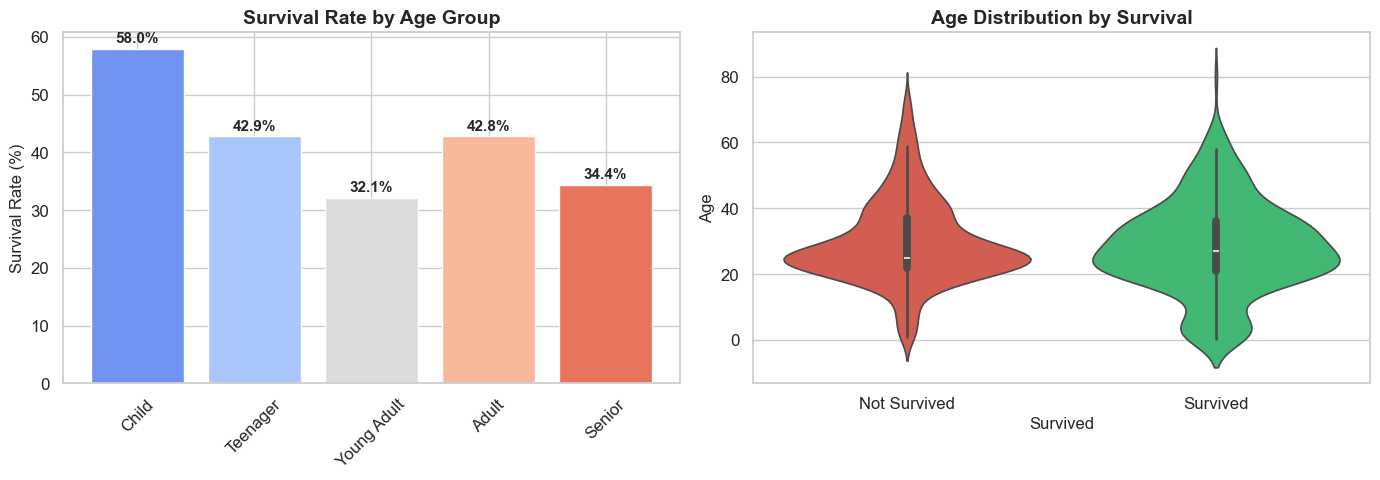


📊 Children had the highest survival rate — "Women and children first" policy confirmed


In [214]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Survival rate by age group
age_survival = train.groupby('AgeGroup', observed=True)['Survived'].mean() * 100
bars = axes[0].bar(age_survival.index.astype(str), age_survival.values,
                    color=sns.color_palette('coolwarm', len(age_survival)), edgecolor='white')
for bar, val in zip(bars, age_survival.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
axes[0].set_title('Survival Rate by Age Group', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].tick_params(axis='x', rotation=45)

# Violin plot: Age by Survival
sns.violinplot(data=train, x='Survived', y='Age', hue='Survived', palette=SURVIVAL_PALETTE, legend=False, ax=axes[1], inner='box')
axes[1].set_title('Age Distribution by Survival', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['Not Survived', 'Survived'])

plt.tight_layout()
plt.show()

print(f'\n📊 Children had the highest survival rate — "Women and children first" policy confirmed')

### 7.6 Survival Rate by Family Size

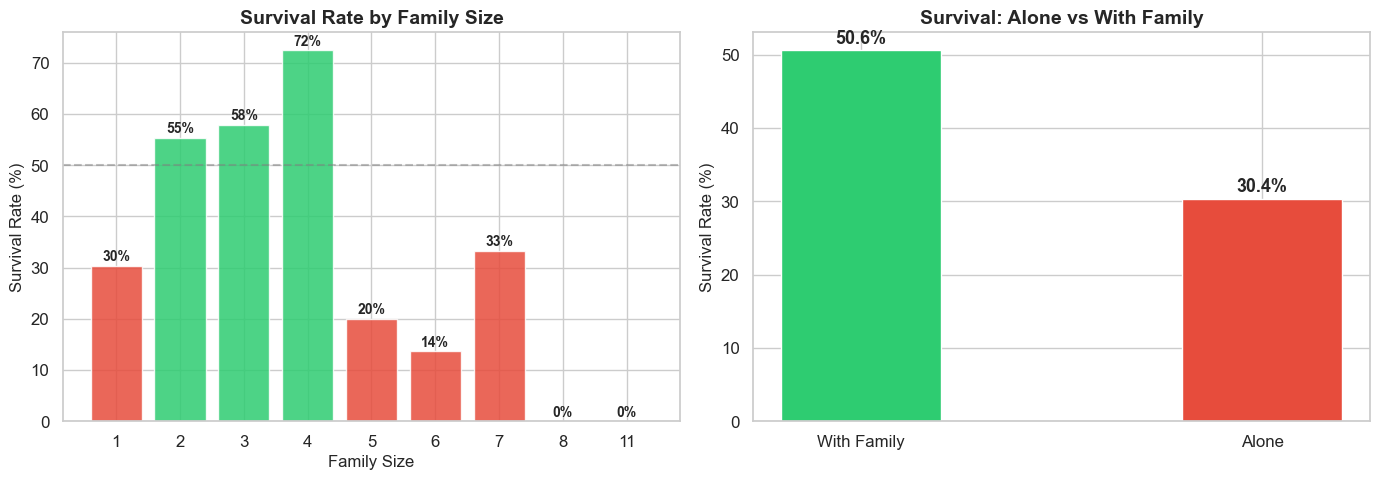


📊 Sweet spot: families of 2-4 had best survival rates
  Very large families (5+) had poor survival — harder to evacuate together


In [215]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Family size survival
fs_survival = train.groupby('FamilySize')['Survived'].mean() * 100
bars = axes[0].bar(fs_survival.index.astype(str), fs_survival.values,
                    color=[COLORS['survived'] if v > 50 else COLORS['not_survived'] for v in fs_survival.values],
                    edgecolor='white', alpha=0.85)
for bar, val in zip(bars, fs_survival.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.0f}%', ha='center', fontweight='bold', fontsize=10)
axes[0].set_title('Survival Rate by Family Size', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Survival Rate (%)')
axes[0].set_xlabel('Family Size')
axes[0].axhline(y=50, color='gray', linestyle='--', alpha=0.5)

# IsAlone comparison
alone_survival = train.groupby('IsAlone')['Survived'].mean() * 100
bars = axes[1].bar(['With Family', 'Alone'], [alone_survival[0], alone_survival[1]],
                    color=[COLORS['survived'], COLORS['not_survived']], edgecolor='white', width=0.4)
for bar, val in zip(bars, [alone_survival[0], alone_survival[1]]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=13)
axes[1].set_title('Survival: Alone vs With Family', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Survival Rate (%)')

plt.tight_layout()
plt.show()

print(f'\n📊 Sweet spot: families of 2-4 had best survival rates')
print(f'  Very large families (5+) had poor survival — harder to evacuate together')

### 7.7 Fare vs Survival

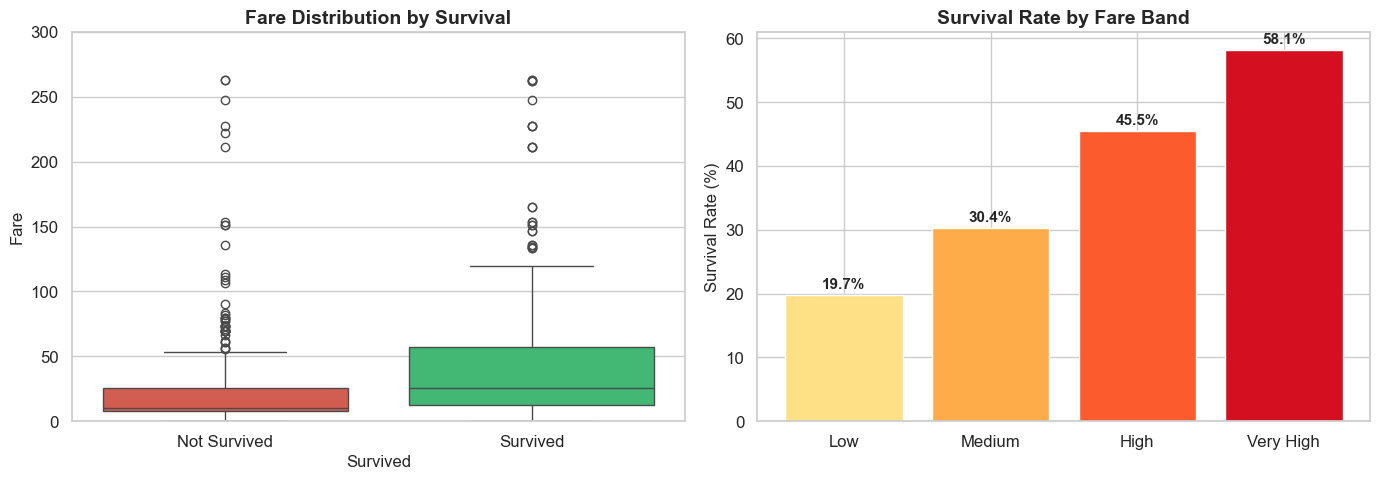


📊 Higher fare = higher survival. "Very High" fare passengers had 58.1% survival rate


In [216]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot
sns.boxplot(data=train, x='Survived', y='Fare', hue='Survived', palette=SURVIVAL_PALETTE, legend=False, ax=axes[0])
axes[0].set_title('Fare Distribution by Survival', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['Not Survived', 'Survived'])
axes[0].set_ylim(0, 300)

# Fare band survival
fb_survival = train.groupby('FareBand', observed=True)['Survived'].mean() * 100
bars = axes[1].bar(fb_survival.index.astype(str), fb_survival.values,
                    color=sns.color_palette('YlOrRd', len(fb_survival)), edgecolor='white')
for bar, val in zip(bars, fb_survival.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
axes[1].set_title('Survival Rate by Fare Band', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Survival Rate (%)')

plt.tight_layout()
plt.show()

print(f'\n📊 Higher fare = higher survival. "Very High" fare passengers had {fb_survival.iloc[-1]:.1f}% survival rate')

---
## 8️⃣ Multivariate Analysis

Exploring complex relationships between multiple variables simultaneously.

### 8.1 Pclass × Sex × Survival

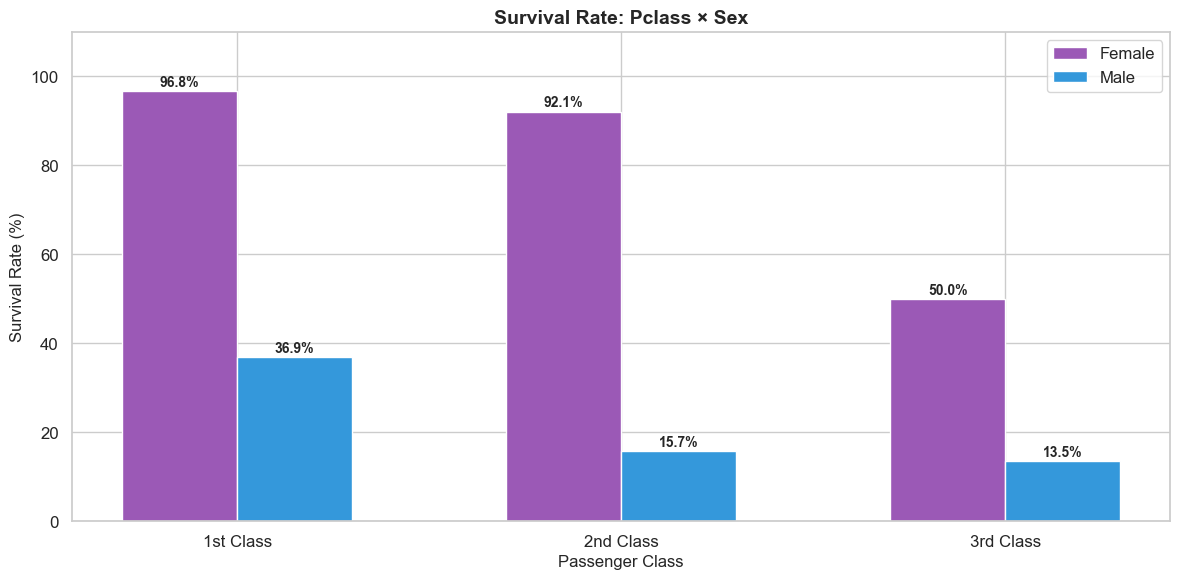


📊 Key Insight: Nearly ALL women in 1st and 2nd class survived
  But only ~50% of 3rd class women survived — class disparity was significant


In [217]:
fig, ax = plt.subplots(figsize=(12, 6))

# Grouped bar chart
cross = train.groupby(['Pclass', 'Sex'])['Survived'].mean() * 100
cross_df = cross.unstack()

x = np.arange(len(cross_df.index))
width = 0.3

bars1 = ax.bar(x - width/2, cross_df['female'], width, label='Female', 
               color=COLORS['secondary'], edgecolor='white')
bars2 = ax.bar(x + width/2, cross_df['male'], width, label='Male',
               color=COLORS['primary'], edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}%', ha='center', fontweight='bold', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.1f}%', ha='center', fontweight='bold', fontsize=10)

ax.set_xlabel('Passenger Class')
ax.set_ylabel('Survival Rate (%)')
ax.set_title('Survival Rate: Pclass × Sex', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['1st Class', '2nd Class', '3rd Class'])
ax.legend(fontsize=12)
ax.set_ylim(0, 110)

plt.tight_layout()
plt.show()

print(f'\n📊 Key Insight: Nearly ALL women in 1st and 2nd class survived')
print(f'  But only ~50% of 3rd class women survived — class disparity was significant')

### 8.2 Age Distribution by Pclass & Survival

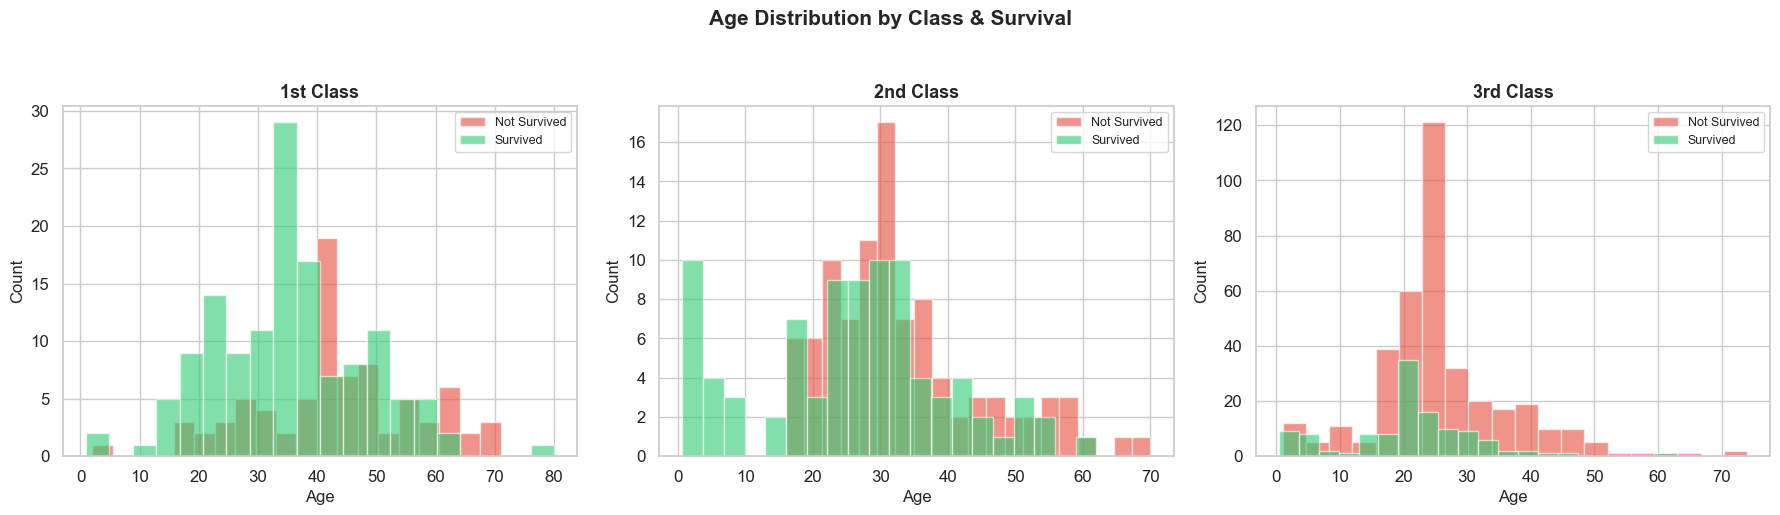


📊 In 3rd class, younger passengers (children) still had higher survival
  In 1st class, most age groups had good survival rates


In [218]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, pclass in enumerate([1, 2, 3]):
    subset = train[train['Pclass'] == pclass]
    axes[i].hist(subset[subset['Survived']==0]['Age'], bins=20, alpha=0.6, 
                 color=COLORS['not_survived'], label='Not Survived', edgecolor='white')
    axes[i].hist(subset[subset['Survived']==1]['Age'], bins=20, alpha=0.6,
                 color=COLORS['survived'], label='Survived', edgecolor='white')
    axes[i].set_title(f'{pclass}{["st","nd","rd"][i]} Class', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Age')
    axes[i].set_ylabel('Count')
    axes[i].legend(fontsize=9)

plt.suptitle('Age Distribution by Class & Survival', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

print(f'\n📊 In 3rd class, younger passengers (children) still had higher survival')
print(f'  In 1st class, most age groups had good survival rates')

### 8.3 Correlation Heatmap

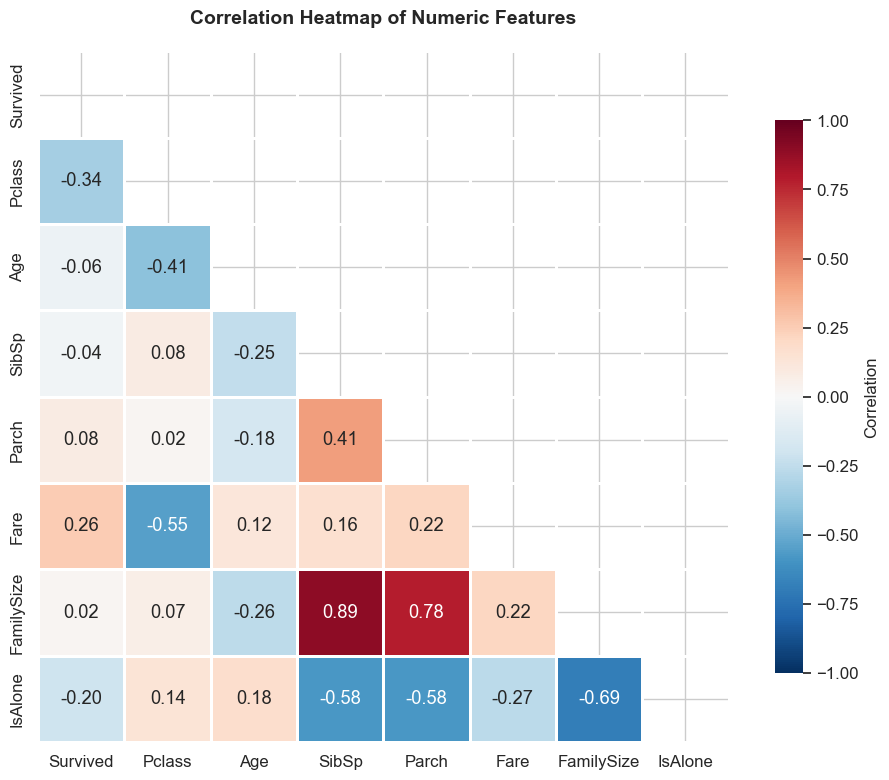


📊 Key Correlations with Survival:
  Pclass      : -0.338 (↓ Negative)
  Fare        : +0.257 (↑ Positive)
  IsAlone     : -0.203 (↓ Negative)
  Parch       : +0.082 (↑ Positive)
  Age         : -0.060 (↓ Negative)
  SibSp       : -0.035 (↓ Negative)
  FamilySize  : +0.017 (↑ Positive)


In [219]:
# Select numeric columns for correlation
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone']
corr_matrix = train[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=1, linecolor='white',
            cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
            vmin=-1, vmax=1, ax=ax)

ax.set_title('Correlation Heatmap of Numeric Features', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print(f'\n📊 Key Correlations with Survival:')
surv_corr = corr_matrix['Survived'].drop('Survived').sort_values(key=abs, ascending=False)
for feat, val in surv_corr.items():
    direction = '↑ Positive' if val > 0 else '↓ Negative'
    print(f'  {feat:<12}: {val:+.3f} ({direction})')

### 8.4 Pairplot of Key Numerical Features

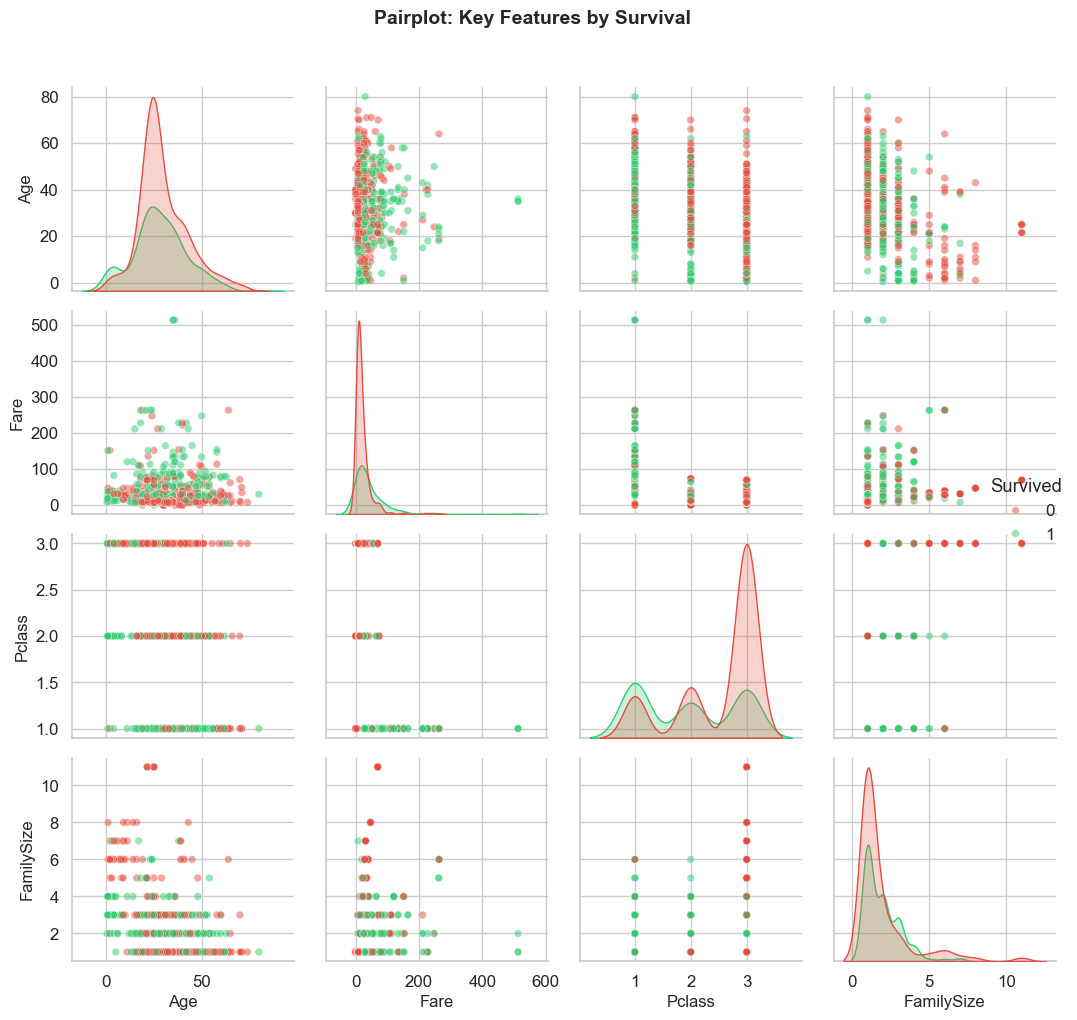


📊 The pairplot reveals clusters — low fare + 3rd class passengers had lowest survival


In [220]:
# Pairplot of key features colored by Survival
pair_cols = ['Survived', 'Age', 'Fare', 'Pclass', 'FamilySize']
g = sns.pairplot(train[pair_cols], hue='Survived', palette=SURVIVAL_PALETTE,
                 diag_kind='kde', plot_kws={'alpha': 0.5, 's': 30, 'edgecolor': 'white'},
                 height=2.5)
g.figure.suptitle('Pairplot: Key Features by Survival', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\n📊 The pairplot reveals clusters — low fare + 3rd class passengers had lowest survival')

### 8.5 Survival Heatmap: Pclass × Sex × AgeGroup

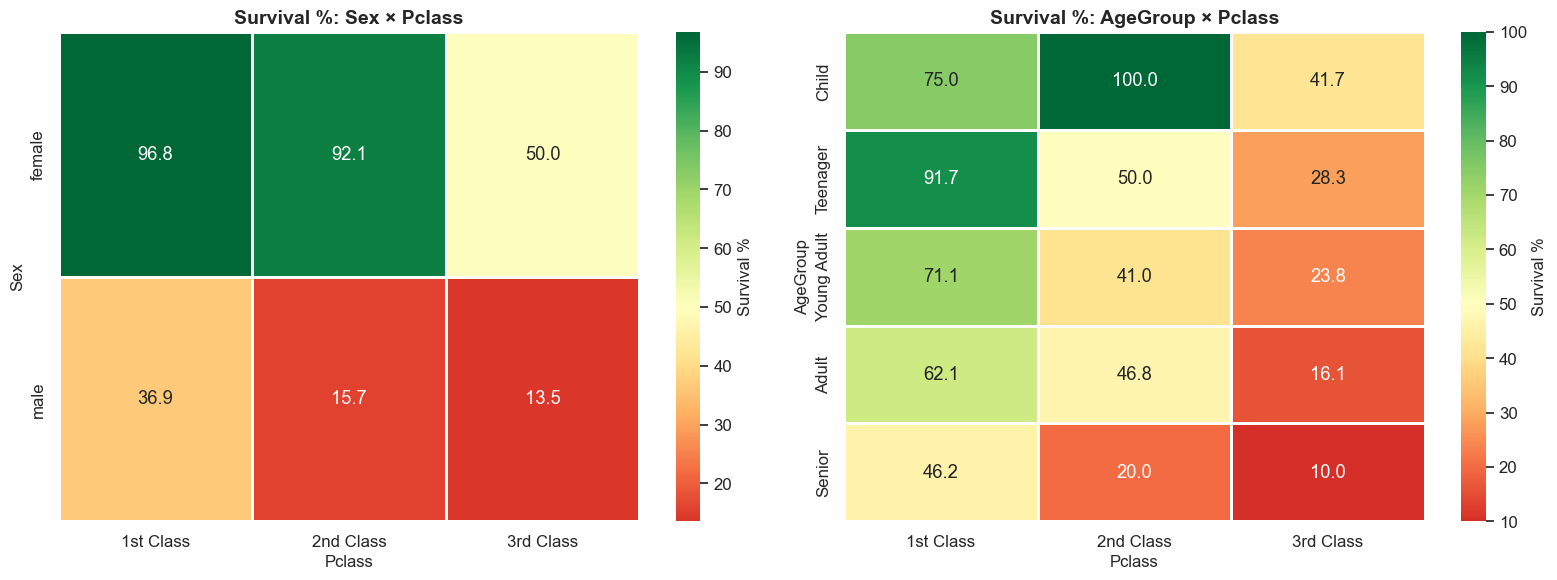


📊 These heatmaps clearly show the "privilege pyramid" of survival:
  Best chance: Female + 1st Class (96.8%)
  Worst chance: Male + 3rd Class (13.5%)


In [221]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap: Sex × Pclass
pivot1 = train.pivot_table(values='Survived', index='Sex', columns='Pclass', aggfunc='mean') * 100
sns.heatmap(pivot1, annot=True, fmt='.1f', cmap='RdYlGn', center=50, ax=axes[0],
            linewidths=2, linecolor='white', cbar_kws={'label': 'Survival %'})
axes[0].set_title('Survival %: Sex × Pclass', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['1st Class', '2nd Class', '3rd Class'])

# Heatmap: AgeGroup × Pclass
pivot2 = train.pivot_table(values='Survived', index='AgeGroup', columns='Pclass', aggfunc='mean') * 100
sns.heatmap(pivot2, annot=True, fmt='.1f', cmap='RdYlGn', center=50, ax=axes[1],
            linewidths=2, linecolor='white', cbar_kws={'label': 'Survival %'})
axes[1].set_title('Survival %: AgeGroup × Pclass', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['1st Class', '2nd Class', '3rd Class'])

plt.tight_layout()
plt.show()

print(f'\n📊 These heatmaps clearly show the "privilege pyramid" of survival:')
print(f'  Best chance: Female + 1st Class (96.8%)')
print(f'  Worst chance: Male + 3rd Class (13.5%)')

### 8.6 Deck Analysis

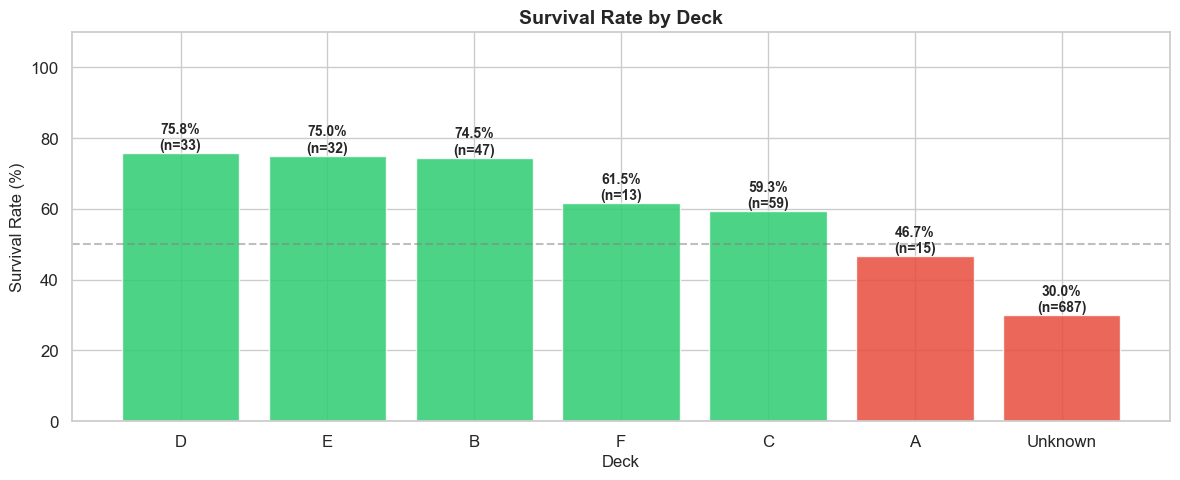


 Upper decks (B, D, E) had higher survival — closer to lifeboats


In [222]:
fig, ax = plt.subplots(figsize=(12, 5))

deck_survival = train.groupby('Deck')['Survived'].agg(['mean', 'count'])
deck_survival = deck_survival[deck_survival['count'] >= 5].sort_values('mean', ascending=False)
deck_survival['mean'] = deck_survival['mean'] * 100

bars = ax.bar(deck_survival.index, deck_survival['mean'],
              color=[COLORS['survived'] if v > 50 else COLORS['not_survived'] for v in deck_survival['mean']],
              edgecolor='white', alpha=0.85)

for bar, (_, row) in zip(bars, deck_survival.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{row["mean"]:.1f}%\n(n={int(row["count"])})', ha='center', fontweight='bold', fontsize=10)

ax.set_title('Survival Rate by Deck', fontsize=14, fontweight='bold')
ax.set_ylabel('Survival Rate (%)')
ax.set_xlabel('Deck')
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5)
ax.set_ylim(0, 110)

plt.tight_layout()
plt.show()

print(f'\n Upper decks (B, D, E) had higher survival — closer to lifeboats')

---
##  Key Findings & Patterns

### Summary of Discoveries

After thorough data cleaning and exploratory analysis, the following key patterns emerge:

---

#### 1.Gender was the strongest predictor of survival
- **Female survival rate: ~74%** vs **Male survival rate: ~19%**
- The "Women and children first" policy was clearly followed
- Nearly all women in 1st and 2nd class survived

#### 2.Socioeconomic status (Pclass) had a major impact
- **1st Class: ~63%**, **2nd Class: ~47%**, **3rd Class: ~24%**
- 1st class passengers had better cabin locations (closer to lifeboats)
- Higher fare correlated strongly with survival

#### 3.Age played a significant role
- **Children (under 12) had the highest survival rate** across all classes
- Elderly passengers had lower survival rates
- The age distribution of survivors was younger than non-survivors

#### 4.Family size affected survival in a non-linear way
- **Solo travelers had lower survival (~30%)** compared to small families
- **Families of 2-4 had the best survival rates (>50%)**
- **Very large families (5+) had poor survival** — harder to evacuate together

#### 5.Embarkation port reflected socioeconomic patterns
- **Cherbourg (C): ~55%** — More 1st class passengers
- **Queenstown (Q): ~39%** — Mostly 3rd class
- **Southampton (S): ~34%** — Mixed, but large 3rd class population

#### 6.Cabin deck location mattered
- Upper decks (B, D, E) had higher survival rates
- Passengers with recorded cabins had ~67% survival vs ~30% without
- Cabin availability itself is a proxy for wealth/class

#### 7.Title (social status indicator) was highly predictive
- **Mrs and Miss** had survival rates above 70%
- **Mr** had a survival rate of only ~16%
- **Master** (young boys) had ~58% survival rate

---

### Overall Conclusion

The Titanic disaster starkly reflected the social hierarchies of the era. **Gender, class, and age** 
were the three most critical factors determining survival. The data clearly shows that **being female, 
wealthy (1st class), and young** gave the best chance of survival, while **being male, poor (3rd class), 
and traveling alone** significantly decreased survival odds.

---
